# Free boundary computation

This file compute the free-boundary case using the optimized PF coils and radial ratios obtained in fixed boundary. Results obtained are compared with ones from `DIIID_baseline_ex.ipynb`, which can be find in https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit/tree/main/src/examples/TokaMaker/DIIID

---

## DIII-D equilibria
- $\textbf{g192185.02440}$
- $\textbf{g174864.02500}$
- $\textbf{g173630.03000}$


# Loading libraries

## Useful libraries

In [2]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt

from helper_fct import ( 
    resize_polygon, place_points, update_boundary, plot_coil
)

plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [3]:
#sys.path.append('/Applications/OpenFUSIONToolkit/python')
home_dir = os.path.expanduser("~")
oft_root_path = os.path.join(home_dir, "OpenFUSIONToolkit/install_release")
os.environ["OFT_ROOTPATH"] = oft_root_path

tokamaker_python_path = os.getenv("OFT_ROOTPATH")

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
    
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh, load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

## 1. Coil position space & machine geometry

The following cell creates the bounds defining the $\textbf{coil position space}$ (CPS). The latter is defined as the area between the curves `coil_center_cand1` & `coil_center_cand2`. Tune these 2 variables to modify the CPS

In [4]:
# Loading machine LCFS & shot from EQDSK file
eqdsk = read_eqdsk('examples/data/eqdsk/g192185.02440') # Machine shot
LCFS_contour = eqdsk['rzout'].copy()

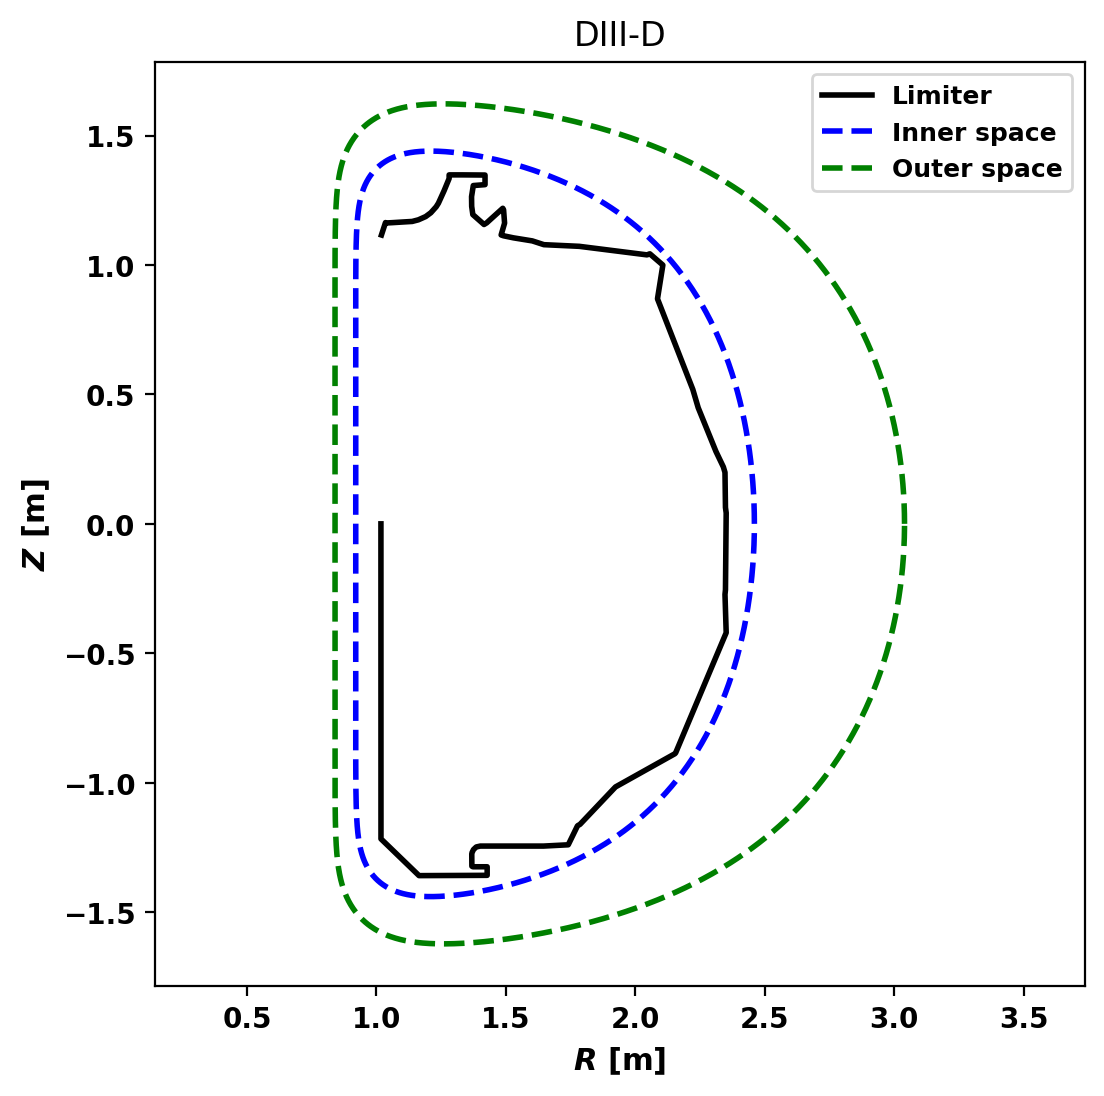

In [5]:
# Geometry
with open('ignore/DIII_D_orig/DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Get the machine limiter
lim0 = np.array(DIIID_geom['limiter'])

### generates a simplified limiter (return a list of (R,Z) coord of plasma bound.)
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) # DIII-D

# inner position space
lim1 = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) # DIII-D  
coil_center_cand1 = resize_polygon(lim1, dx=0.1)

# outer position space
lim2 = update_boundary(r0=1.94, z0=0, a0=0.95, kappa=1.55, delta=0.8, squar=0.15, npts=1700) # DIII-D 
coil_center_cand2 = resize_polygon(lim2, dx=0.15)     

# Plot geometry & coil position space
plt.figure(figsize=(6, 6))
plt.plot(lim0[:,0], lim0[:,1], 'k', label='Limiter')
#plt.plot(lim1[:,0], lim1[:,1], 'r--', label='Simpler limiter')
plt.plot(coil_center_cand1[:,0], coil_center_cand1[:,1], 'b--', label='Inner space')
plt.plot(coil_center_cand2[:,0], coil_center_cand2[:,1], 'g--', label='Outer space')

plt.title('DIII-D')
plt.xlabel('$R$ [m]', fontsize=11)
plt.ylabel('$Z$ [m]', fontsize=11)
plt.axis('equal')
plt.legend(fontsize=9)

In [6]:
def place_points_pol_rad(ncoils, arc_inner, arc_outer, pol_angles, radials):
    """
    Places coils inside a strip defined by two curves (arc_inner, arc_outer)
    based on poloidal angle and radial offset.

    Parameters:
        - ncoils : (int) Number of coils in upper side
        - arc_inner : ndarray (N,2)
        - Inner curve coordinates (R,Z)
        - arc_outer : ndarray (N,2)
        - Outer curve coordinates (R,Z) 
        - pol_angles : Poloidal angles (degrees)
        - radials : Radial ratios

    Returns
        - inds : Indices along the arc (based on arc_inner indexing).
        - locs : ndarray (ncoils,2) Coil (R,Z) coordinates.
    """
    if len(pol_angles) != ncoils or len(radials) != ncoils:
        raise ValueError("Length of pol_angles and radials must match ncoils.")

    # Create a mapping from poloidal angle to index along arc
    theta_range = np.linspace(0, 180, len(arc_inner))  # top half
    pol_angles = np.asarray(pol_angles)

    inds = []
    locs = []

    for theta, rho in zip(pol_angles, radials):
        # Interpolate R and Z along each arc at this theta
        R_inner = np.interp(theta, theta_range, arc_inner[:, 0])
        Z_inner = np.interp(theta, theta_range, arc_inner[:, 1])
        R_outer = np.interp(theta, theta_range, arc_outer[:, 0])
        Z_outer = np.interp(theta, theta_range, arc_outer[:, 1])

        # Interpolate between inner and outer curves based on rho
        R_pos = (1 - rho) * R_inner + rho * R_outer
        Z_pos = (1 - rho) * Z_inner + rho * Z_outer

        # Approximate index based on inner arc position
        idx = int(np.interp(theta, theta_range, np.arange(len(arc_inner))))

        inds.append(idx)
        locs.append([R_pos, Z_pos])

    return np.array(inds), np.array(locs)

In [7]:
def make_new_coils(params, nCoils, dx=0.08, dy=0.08, params2=None, ifplot=True):
    """
    Generates and places poloidal field (PF) coils given their poloidal angles and radial ratios. 
    It creates a set of coil pairs (one above and one below the midplane) whose size can be changed 
    thanks to dx & dy. Optionally plots two coil configurations.

    Parameters:
        - params: list of poloidal angles (degrees) and their radial ratios (between 0 and 1)
        - nCoils: Number of coils (in the top-side)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - params2: (Optional) second list of poloidal angles and radial ratios
        - ifplot: Boolean, whether to plot the given coil distribution

    Returns:
        - scan_geom (dictionary): Dict. containing the data of the coil distr.
    """
    # Loading poloidal angles (thetas) and radial ratios (radials)
    thetas = params[:nCoils]
    radials = params[nCoils:2*nCoils]
    
    # Creating dict.
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas, radials)
    
    # Creating coil pairs for (1st) distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    # Plotting the coil distribution
    if ifplot:
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        #plt.plot(lim1[:, 0], lim1[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                #plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')

        # If provided, plot the (2nd) distrib in red
        if params2 is not None:
            thetas2 = params2[:nCoils]
            radials2 = params2[nCoils:2*nCoils]

            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas2, radials2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for the 2nd distrib
                scan_geom_2["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils 
            for coil in scan_geom_2["coils"]:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    #plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')


    return scan_geom

# 2. Meshing

### Set mesh resolution for each region
First we define some target sizes to set the resolution in our free-boundary grid. These variables will be used later and represent the target edge size within a given region, where units are in meters

In [8]:
plasma_dx = 0.01
coil_dx = 0.005
vac_dx = 0.04
vv_dx = 0.04

Load here the optimized configuration of PF coils in upper-side and radial ratios obtained in the $\textbf{fixed boundary case}$

In [9]:
from pathlib import Path

for f in Path('examples/comparisons/closed_boundary_DIIID/free_boundary_test/').rglob('*.json'):
    print(f)
    results = json.loads(f.read_text())
    for method in results["methods"]:
        print(results["methods"][method]["parameters"])


examples/comparisons/closed_boundary_DIIID/free_boundary_test/lambda:1e-07,coils:4 copy/run_00/results.json
{'thetas': [130.10552298600658, 52.973966832912446, 16.330566850884775, 147.5737264990956], 'radials': [0.0, 0.4651345636996718, 0.4242794751100666, 0.019616266628504103]}
{'thetas': [52.92475168056597, 16.32892858009234, 147.48465893916475, 130.3539167294957], 'radials': [0.4624016099222366, 0.42414791858231976, 0.00012181336740633311, 0.0]}


In [10]:

# top_coils = [7.9550895237158805, 18.689102632474277, 47.6967448776751, 171.6356210910371, 177.65850865332487]
# radials = [0.051990612458852364, 0.0, 0.0, 0.0, 0.2544729904764001]

top_coils = [130.10552298600658, 52.973966832912446, 16.330566850884775, 147.5737264990956]
radials = [0.0, 0.4651345636996718, 0.4242794751100666, 0.019616266628504103]
params = top_coils + radials

Loading th PF coils informations for creating the mesh

In [11]:
scan_geom_DIIID = make_new_coils(params, len(params) // 2, dx=0.03, dy=0.03, ifplot=False)

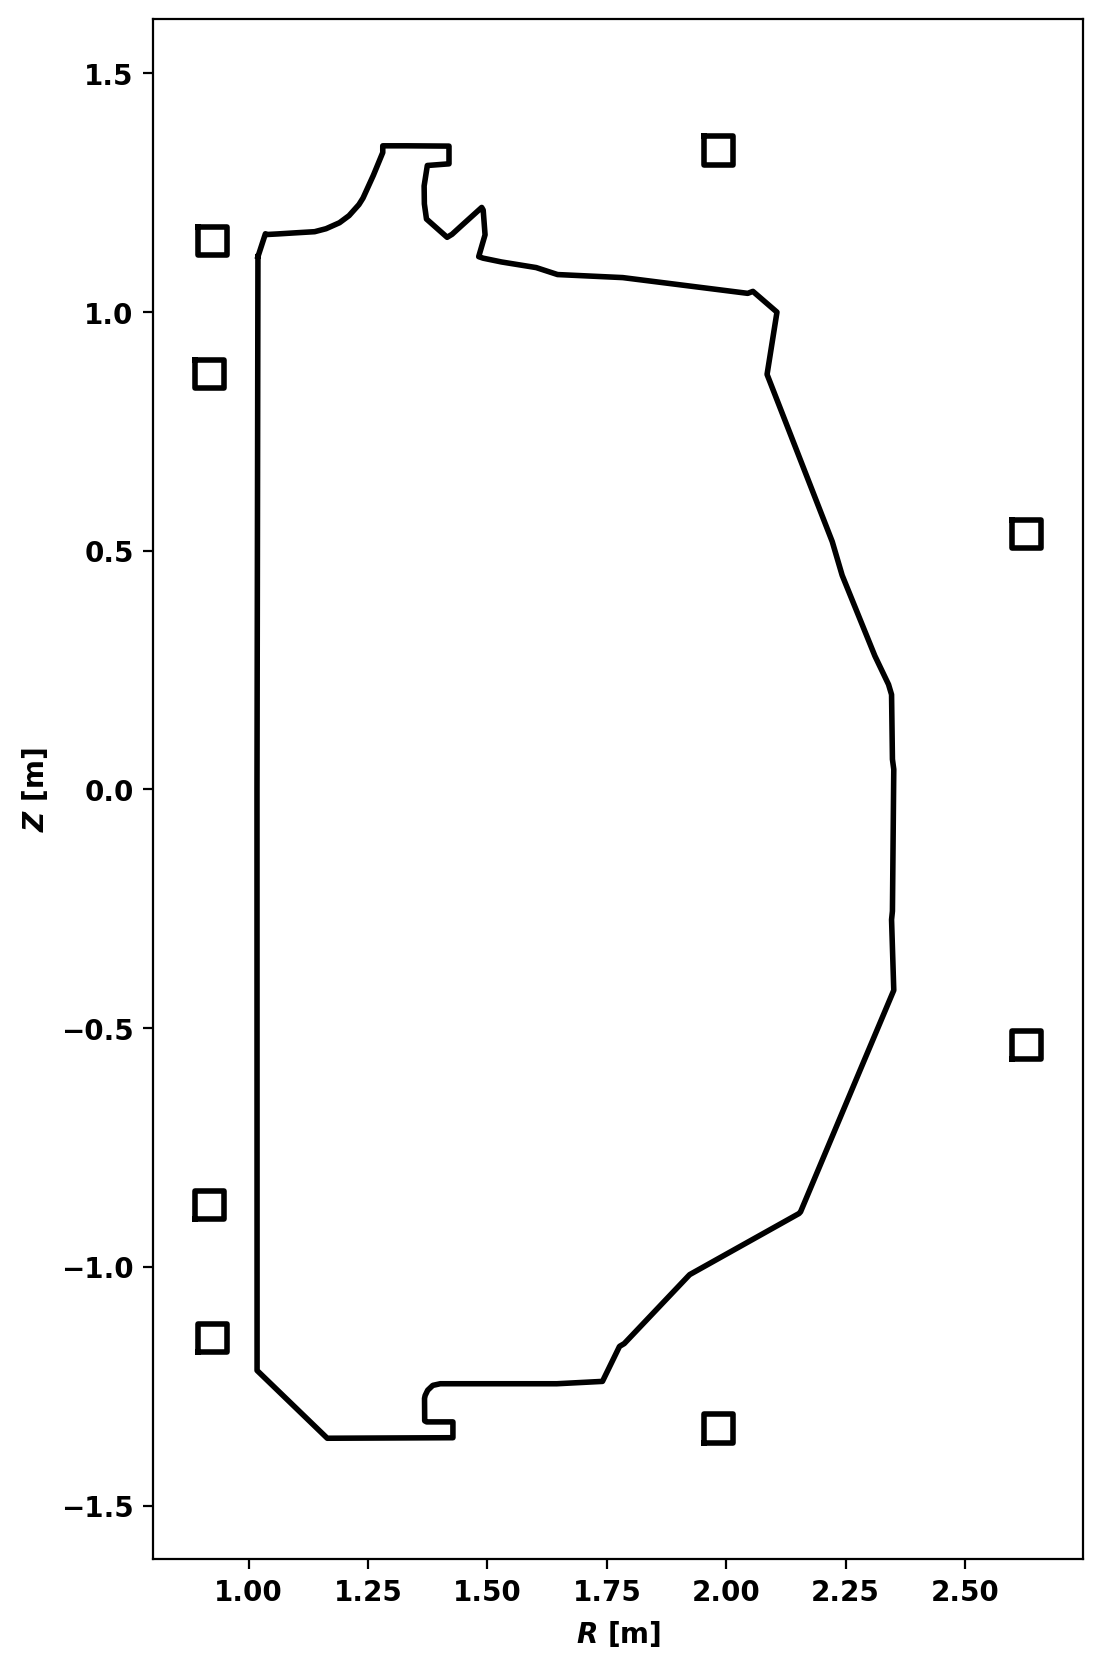

In [12]:
# Visualization
_ = make_new_coils(params, len(params) // 2, dx=0.03, dy=0.03, ifplot=True)

### Create mesh
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. Additionally, if `coil` and/or `conductor` regions are defined the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_coils "get_coils" and \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_conductors "get_conductors" methods should also be called to get descriptive dictionaries for later use in TokaMaker. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

### Plot resulting regions and grid
We now plot the mesh by region to inspect proper generation.

In [13]:
# do not save the mesh in script

# Creates a Grad-Shafranov (GS) mesh domain for the magnetic equilibrium
def make_mesh(DIIID_geom, scan_geom, savename = 'DIIID_mesh_scantest.h5', ifplot = True):
    
    # Create a G-S domain
    gs_mesh = gs_Domain()
    # Define region information for mesh
    gs_mesh.define_region('air',vac_dx,'boundary')                     # Define the bounding region
    gs_mesh.define_region('plasma',plasma_dx,'plasma')                 # Define the plasma region and resolution
    gs_mesh.define_region('vacuum',vv_dx,'vacuum',allow_xpoints=True)  # Define the vacuum inside the VV
    gs_mesh.define_region('vv',vv_dx,'conductor',eta=6e-07)            # Define one region for VV 

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        if key.startswith('ECOIL'):
            for i, subcoil in enumerate(coil):
                gs_mesh.define_region('{0}_{1}'.format(key,i),coil_dx,'coil',coil_set=key,nTurns=subcoil["nturns"])
        else:
            gs_mesh.define_region(key,coil_dx,'coil',nTurns=coil["nturns"])

    # Define geometry, using the fake limiter
    gs_mesh.add_polygon(lim,'plasma',parent_name='vacuum') 
    gs_mesh.add_annulus(resize_polygon(lim, 0.01),'vacuum',resize_polygon(lim, 0.05),'vv')
    
    gs_mesh.add_enclosed([1.75,1.25],'vacuum')

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        gs_mesh.add_polygon(coil["pts"],key,parent_name='air')

    # Create mesh
    mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
    coil_dict = gs_mesh.get_coils()
    cond_dict = gs_mesh.get_conductors()

    # Plot result
    if ifplot:
        fig, ax = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)
        gs_mesh.plot_mesh(fig,ax)

    # Save mesh for later use
    save_gs_mesh(mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict,savename) # Save G-S mesh to file in HDF5 format (.h5)

    return coil_dict, cond_dict

### LETS ADD A SOLENOID CURRENT ###

In [14]:
# add this later 

# # ECOILA position
# scan_geom_DIIID['coils']['E0'] = {}
# scan_geom_DIIID['coils']['E0']['pts'] = np.array([[0.658165, -1.57925], [0.716835, -1.57925], [0.716835, 1.57925], [0.658165, 1.57925]])
# scan_geom_DIIID['coils']['E0']['nturns'] = 1.0

# # ECOILB position
# scan_geom_DIIID['coils']['E1'] = {}
# scan_geom_DIIID['coils']['E1']['pts'] = np.array([[0.728165, -1.57925], [0.786835, -1.57925], [0.786835, 1.57925], [0.728165, 1.57925]])
# scan_geom_DIIID['coils']['E1']['nturns'] = 1.0

Creating a mesh with optimized distribution with solenoids (depending on resolution, can take a few minutes)

In [ ]:
coil_dict_sol, cond_dict_sol = make_mesh(DIIID_geom, scan_geom_DIIID, savename = 'DIIID_mesh_scantest_withSolenoid.h5')

Assembling regions:
  # of unique points    = 1740
  # of unique segments  = 39


In [ ]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('DIIID_mesh_scantest_withSolenoid.h5')
mygs.setup_mesh(mesh_pts,mesh_lc,mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.free_boundary = True # free boundary

F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2,F0=F0) # F0: vacuum F value

In [ ]:
fixed_mag_axis = np.array([1.77764093, -0.04014656])
Ip_target = eqdsk['ip']
R0_target = fixed_mag_axis[0].item()
Z0 = fixed_mag_axis[1].item()
mygs.set_targets(Ip=Ip_target, R0=R0_target, V0=Z0)

### Define hard limits on coil currents
coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

In [ ]:
isoflux_pts = eqdsk['rzout'].copy()
index = 55 # tune
weights = np.ones(len(isoflux_pts[:,0]))
weights[index] = 1e4 # X-point weight
mygs.set_isoflux(isoflux_pts, weights=weights)


In [ ]:
def set_regularization(mygs_obj, weight_curr=1.E-2):
    regularization_terms = []
    for name, coil in mygs.coil_sets.items():
        regularization_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight_curr)) 
            # fixing coil currents to 0 but allowing them to move
    mygs_obj.set_coil_reg(reg_terms=regularization_terms)
    # Pass regularization terms to TokaMaker

In [ ]:
coil_names = list(mygs.coil_sets.keys())
# weights = [1.E-5, 1.E-4, 1.E-3, 1.E-2, 1E-1, 1]
weights = [1.E-5]
coil_currents = np.zeros((len(coil_names), len(weights)))

# make mygs? 
for i, w in enumerate(weights): 
    set_regularization(mygs, w)
    mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288) 
    err_flag = mygs.solve()

    currents, currents_reg = mygs.get_coil_currents()
    coil_currents[:, i] = np.array([currents[name] for name in coil_names])

Starting non-linear GS solver
     1  6.2680E-03  2.1729E-01  2.4237E-03  1.8172E+00 -3.9265E-02 -0.0000E+00
     2  4.0993E-01  1.5419E-01  4.6429E-04  1.8099E+00 -3.9692E-02 -0.0000E+00
     3  5.7970E-01  1.2660E-01  6.0452E-04  1.8020E+00 -3.9923E-02 -0.0000E+00
     4  6.8564E-01  1.0897E-01  5.1431E-04  1.7956E+00 -4.0041E-02 -0.0000E+00
     5  7.7265E-01  9.4397E-02  4.2824E-04  1.7904E+00 -4.0094E-02 -0.0000E+00
     6  8.5325E-01  8.0874E-02  3.7874E-04  1.7858E+00 -4.0117E-02 -0.0000E+00
     7  9.3133E-01  6.7769E-02  3.5383E-04  1.7815E+00 -4.0122E-02 -0.0000E+00
     8  9.4930E-01  6.4645E-02  1.8246E-04  1.7793E+00 -4.0117E-02 -0.0000E+00
     9  9.5373E-01  6.3846E-02  8.0720E-05  1.7783E+00 -4.0111E-02 -0.0000E+00
    10  9.5490E-01  6.3628E-02  3.3436E-05  1.7779E+00 -4.0108E-02 -0.0000E+00
    11  9.5523E-01  6.3566E-02  1.3370E-05  1.7777E+00 -4.0105E-02 -0.0000E+00
    12  9.5531E-01  6.3547E-02  5.2281E-06  1.7777E+00 -4.0104E-02 -0.0000E+00
    13  9.5534E-01  6.

In [ ]:
# cost function 
# solve fixed boundary -> use final coil placements 

# solve free boundary (input = coil placements)

# difference between fixed lcfs ('rzout') and free boundary lcfs 
    # the line technique
    # # in documentation, find a way to find rzout of free boundary 
    # fixed_mag_axis is the center of fixed boundary 

# cost = fixed * (1-alpha) + free * alpha 
# where alpha between 0,1 


# penalty of current? just do the same thing 




Assembling regions:
  # of unique points    = 1832
  # of unique segments  = 47
Generating mesh with Triangle:
  # of points  = 56640
  # of cells   = 112958
  # of regions = 14
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          e2083e8
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/oft_77966/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.040E+01
    # of points  =   56640
    # of edges   =  169597
    # of cells   =  112958
    # of boundary points =     320
    # of boundary edges  =     320


     3  5.7933E-01  1.2672E-01  2.5205E-04  1.8016E+00 -3.9536E-02 -0.0000E+00
     4  6.8467E-01  1.0929E-01  2.9125E-04  1.7953E+00 -3.9690E-02 -0.0000E+00
     5  7.7068E-01  9.4938E-02  3.7946E-04  1.7902E+00 -3.9783E-02 -0.0000E+00
     6  8.5024E-01  8.1622E-02  4.0714E-04  1.7856E+00 -3.9835E-02 -0.0000E+00
     7  9.2727E-01  6.8713E-02  4.1322E-04  1.7814E+00 -3.9873E-02 -0.0000E+00
     8  9.4505E-01  6.5633E-02  2.1732E-04  1.7792E+00 -3.9886E-02 -0.0000E+00
     9  9.4948E-01  6.4838E-02  9.7866E-05  1.7783E+00 -3.9889E-02 -0.0000E+00
    10  9.5067E-01  6.4617E-02  4.1540E-05  1.7779E+00 -3.9889E-02 -0.0000E+00
    11  9.5102E-01  6.4551E-02  1.7203E-05  1.7777E+00 -3.9888E-02 -0.0000E+00
    12  9.5112E-01  6.4531E-02  7.0607E-06  1.7777E+00 -3.9888E-02 -0.0000E+00
    13  9.5115E-01  6.4524E-02  2.8945E-06  1.7777E+00 -3.9887E-02 -0.0000E+00
    14  9.5116E-01  6.4522E-02  1.1902E-06  1.7776E+00 -3.9887E-02 -0.0000E+00
    15  9.5116E-01  6.4522E-02  4.9196E-07  1.7776E+

Starting non-linear GS solver
     1  6.4853E-04  2.1781E-01  6.5547E-03  1.8169E+00 -3.8865E-02 -0.0000E+00
     2  4.0857E-01  1.5430E-01  1.5788E-03  1.8095E+00 -3.9273E-02 -0.0000E+00
     3  5.7933E-01  1.2672E-01  2.5212E-04  1.8016E+00 -3.9536E-02 -0.0000E+00
     4  6.8467E-01  1.0929E-01  2.9100E-04  1.7953E+00 -3.9691E-02 -0.0000E+00
     5  7.7068E-01  9.4937E-02  3.7916E-04  1.7902E+00 -3.9783E-02 -0.0000E+00
     6  8.5025E-01  8.1621E-02  4.0684E-04  1.7856E+00 -3.9835E-02 -0.0000E+00
     7  9.2728E-01  6.8712E-02  4.1292E-04  1.7814E+00 -3.9873E-02 -0.0000E+00
     8  9.4505E-01  6.5632E-02  2.1718E-04  1.7792E+00 -3.9886E-02 -0.0000E+00
     9  9.4948E-01  6.4837E-02  9.7813E-05  1.7783E+00 -3.9889E-02 -0.0000E+00
    10  9.5068E-01  6.4616E-02  4.1520E-05  1.7779E+00 -3.9889E-02 -0.0000E+00
    11  9.5102E-01  6.4550E-02  1.7195E-05  1.7777E+00 -3.9888E-02 -0.0000E+00
    12  9.5112E-01  6.4530E-02  7.0580E-06  1.7777E+00 -3.9888E-02 -0.0000E+00
    13  9.5115E-01  6.

     3  5.7956E-01  1.2663E-01  2.5766E-04  1.8016E+00 -3.9556E-02 -0.0000E+00
     4  6.8494E-01  1.0919E-01  2.6852E-04  1.7953E+00 -3.9710E-02 -0.0000E+00
     5  7.7097E-01  9.4835E-02  3.5195E-04  1.7902E+00 -3.9801E-02 -0.0000E+00
     6  8.5053E-01  8.1520E-02  3.7915E-04  1.7857E+00 -3.9852E-02 -0.0000E+00
     7  9.2755E-01  6.8612E-02  3.8544E-04  1.7814E+00 -3.9889E-02 -0.0000E+00
     8  9.4533E-01  6.5533E-02  2.0430E-04  1.7792E+00 -3.9901E-02 -0.0000E+00
     9  9.4977E-01  6.4739E-02  9.2697E-05  1.7783E+00 -3.9904E-02 -0.0000E+00
    10  9.5096E-01  6.4519E-02  3.9612E-05  1.7779E+00 -3.9903E-02 -0.0000E+00
    11  9.5130E-01  6.4453E-02  1.6496E-05  1.7777E+00 -3.9903E-02 -0.0000E+00
    12  9.5140E-01  6.4433E-02  6.8019E-06  1.7777E+00 -3.9902E-02 -0.0000E+00
    13  9.5143E-01  6.4427E-02  2.7993E-06  1.7777E+00 -3.9902E-02 -0.0000E+00
    14  9.5143E-01  6.4425E-02  1.1550E-06  1.7776E+00 -3.9902E-02 -0.0000E+00
    15  9.5144E-01  6.4424E-02  4.7889E-07  1.7776E+

Starting non-linear GS solver
     1  8.6011E-04  2.1748E-01  9.1489E-04  1.8171E+00 -3.9126E-02 -0.0000E+00
     2  4.0945E-01  1.5354E-01  3.5848E-04  1.8098E+00 -3.9561E-02 -0.0000E+00
     3  5.8130E-01  1.2564E-01  2.0792E-04  1.8018E+00 -3.9817E-02 -0.0000E+00
     4  6.8726E-01  1.0806E-01  1.4413E-04  1.7954E+00 -3.9957E-02 -0.0000E+00
     5  7.7349E-01  9.3652E-02  1.1485E-04  1.7902E+00 -4.0033E-02 -0.0000E+00
     6  8.5307E-01  8.0335E-02  1.0189E-04  1.7857E+00 -4.0069E-02 -0.0000E+00
     7  9.3005E-01  6.7446E-02  9.6087E-05  1.7814E+00 -4.0092E-02 -0.0000E+00
     8  9.4793E-01  6.4366E-02  5.1270E-05  1.7792E+00 -4.0097E-02 -0.0000E+00
     9  9.5238E-01  6.3583E-02  2.3506E-05  1.7783E+00 -4.0096E-02 -0.0000E+00
    10  9.5354E-01  6.3373E-02  1.0097E-05  1.7779E+00 -4.0095E-02 -0.0000E+00
    11  9.5386E-01  6.3314E-02  4.1970E-06  1.7777E+00 -4.0094E-02 -0.0000E+00
    12  9.5395E-01  6.3298E-02  1.7152E-06  1.7777E+00 -4.0093E-02 -0.0000E+00
    13  9.5397E-01  6.

Starting non-linear GS solver
     1 -1.0722E-02  2.1820E-01  3.8512E-04  1.8171E+00 -3.9536E-02 -0.0000E+00
     2  4.0015E-01  1.5371E-01  1.8575E-04  1.8096E+00 -4.0072E-02 -0.0000E+00
     3  5.6882E-01  1.2618E-01  1.2064E-04  1.8015E+00 -4.0452E-02 -0.0000E+00
     4  6.7091E-01  1.0911E-01  8.3808E-05  1.7952E+00 -4.0701E-02 -0.0000E+00
     5  7.5353E-01  9.5204E-02  6.4113E-05  1.7900E+00 -4.0854E-02 -0.0000E+00
     6  8.2975E-01  8.2361E-02  5.4398E-05  1.7856E+00 -4.0963E-02 -0.0000E+00
     7  9.0352E-01  6.9929E-02  4.9859E-05  1.7814E+00 -4.1052E-02 -0.0000E+00
     8  9.2023E-01  6.7000E-02  2.6366E-05  1.7792E+00 -4.1095E-02 -0.0000E+00
     9  9.2423E-01  6.6262E-02  1.2115E-05  1.7783E+00 -4.1112E-02 -0.0000E+00
    10  9.2525E-01  6.6062E-02  5.2624E-06  1.7779E+00 -4.1118E-02 -0.0000E+00
    11  9.2552E-01  6.6004E-02  2.2280E-06  1.7777E+00 -4.1116E-02 -0.0000E+00
    12  9.2559E-01  6.5986E-02  9.3234E-07  1.7777E+00 -4.1116E-02 -0.0000E+00
 Timing:  0.8940769999

Starting non-linear GS solver
     1  1.7733E-01  1.5906E-01  3.7383E-04  1.8362E+00 -8.8023E-02 -0.0000E+00
     2  4.0158E-01  1.1942E-01  2.1101E-04  1.8293E+00 -9.8983E-02 -0.0000E+00
     3  5.4927E-01  9.3731E-02  1.3226E-04  1.8197E+00 -1.0647E-01 -0.0000E+00
     4  6.7348E-01  7.2978E-02  9.4998E-05  1.8104E+00 -1.1126E-01 -0.0000E+00
     5  7.8932E-01  5.3880E-02  7.8576E-05  1.8017E+00 -1.1417E-01 -0.0000E+00
     6  9.0269E-01  3.5262E-02  7.1911E-05  1.7933E+00 -1.1591E-01 -0.0000E+00
     7  1.0152E+00  1.6781E-02  6.9347E-05  1.7851E+00 -1.1688E-01 -0.0000E+00
     8  1.0450E+00  1.1994E-02  3.5848E-05  1.7808E+00 -1.1726E-01 -0.0000E+00
     9  1.0545E+00  1.0589E-02  1.6153E-05  1.7789E+00 -1.1734E-01 -0.0000E+00
    10  1.0581E+00  1.0114E-02  7.1082E-06  1.7781E+00 -1.1732E-01 -0.0000E+00
    11  1.0598E+00  9.9308E-03  3.2435E-06  1.7778E+00 -1.1727E-01 -0.0000E+00
    12  1.0605E+00  9.8510E-03  1.5843E-06  1.7777E+00 -1.1723E-01 -0.0000E+00
    13  1.0609E+00  9.

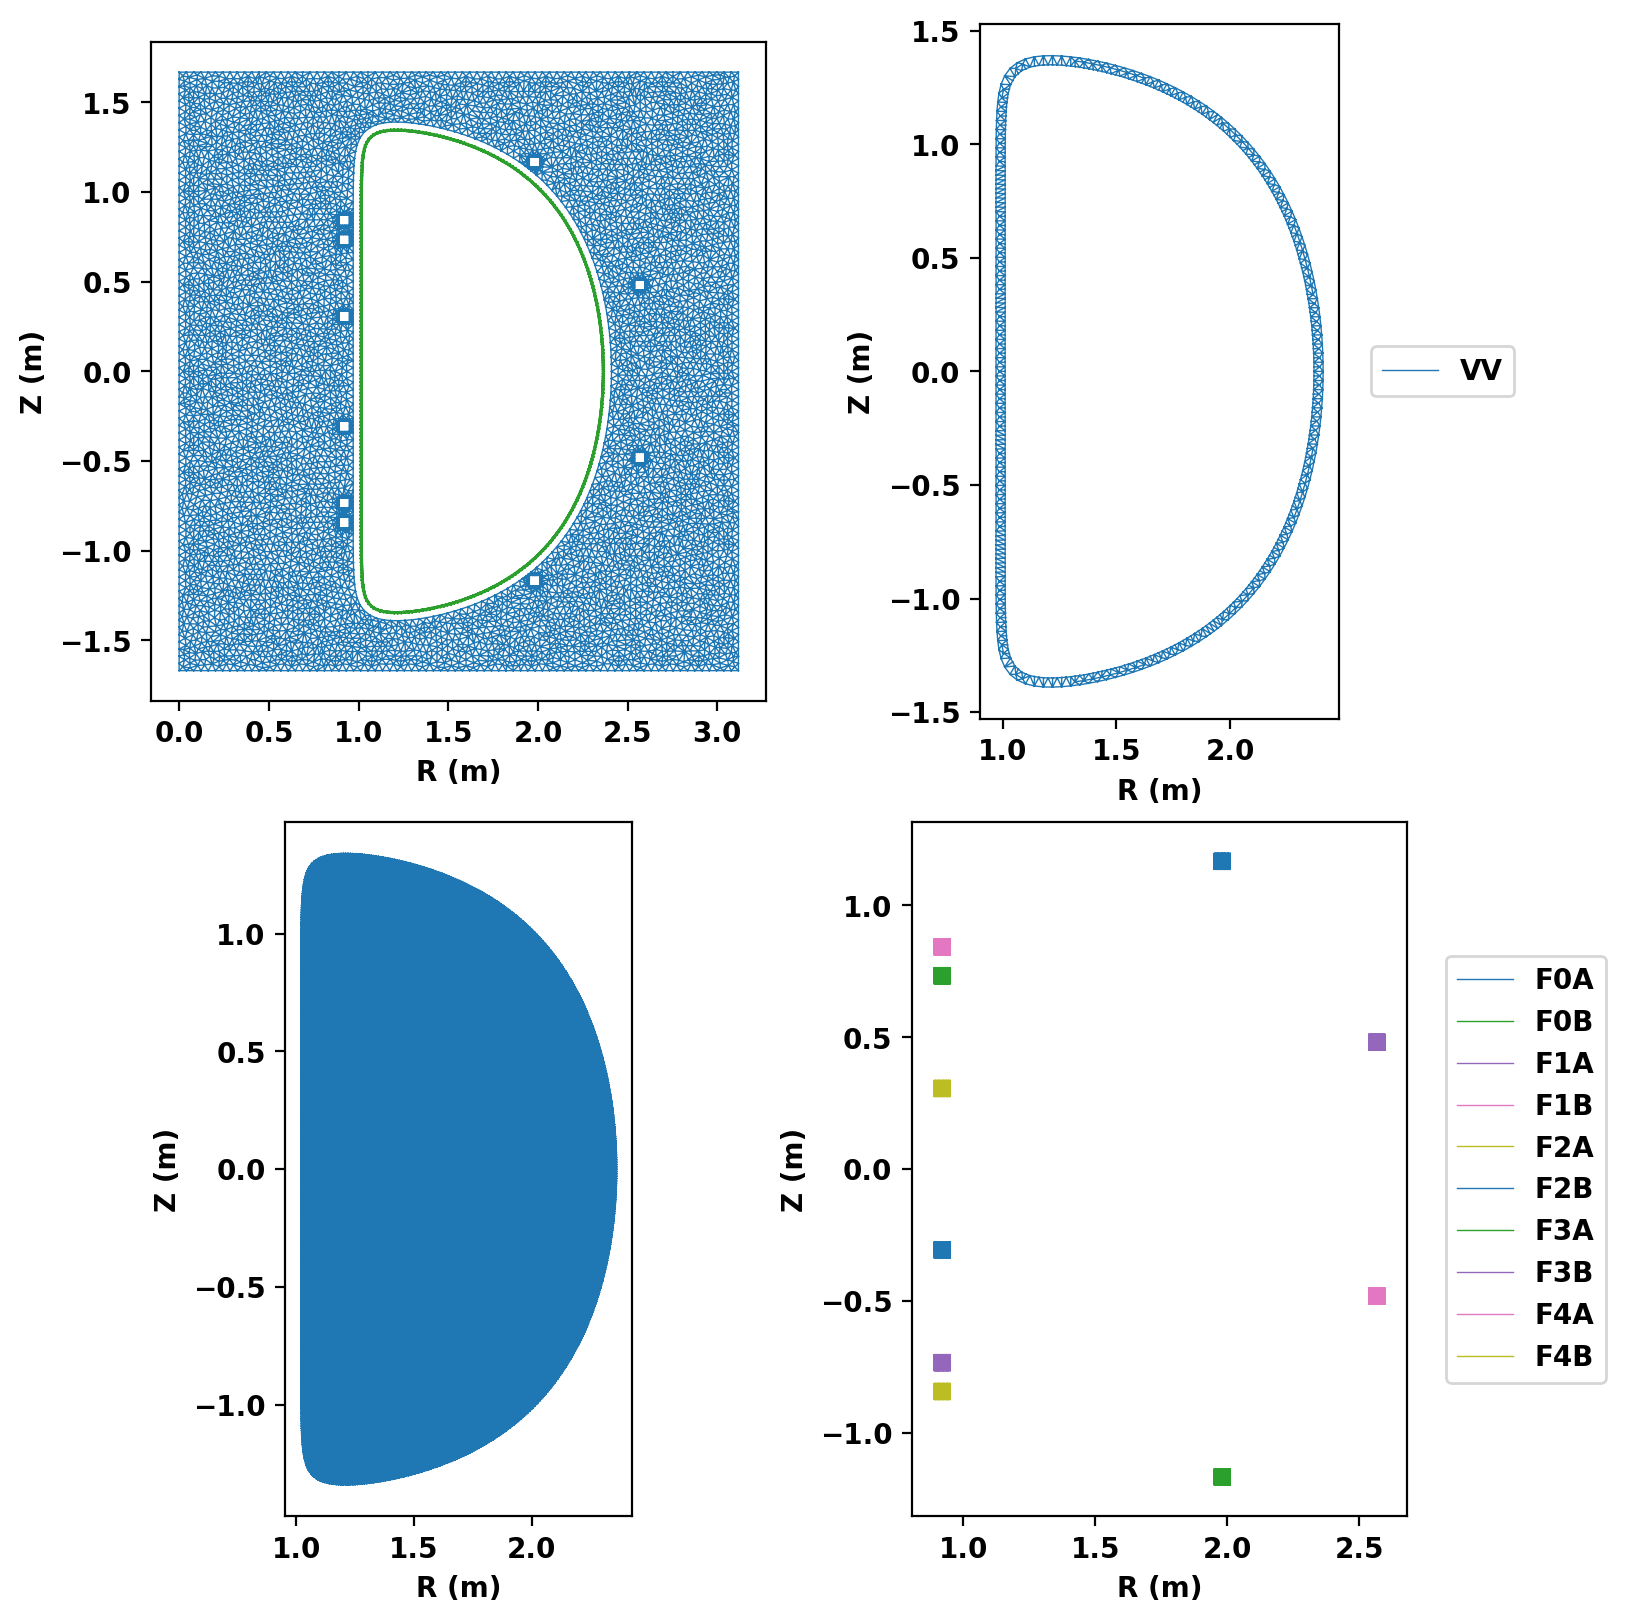

In [1]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from helper_fct import ( 
    resize_polygon, place_points, update_boundary, plot_coil
)

plt.rcParams["figure.figsize"]=(6,6)
plt.rcParams["font.weight"]="bold"
plt.rcParams["axes.labelweight"]="bold"
plt.rcParams["lines.linewidth"]=2
plt.rcParams["lines.markeredgewidth"]=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# importing tokamaker 
home_dir = os.path.expanduser("~")
oft_root_path = os.path.join(home_dir, "OpenFUSIONToolkit/install_release")
os.environ["OFT_ROOTPATH"] = oft_root_path
tokamaker_python_path = os.getenv("OFT_ROOTPATH")

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,"python"))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh, load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk


# Loading machine LCFS & shot from EQDSK file
eqdsk = read_eqdsk("examples/data/eqdsk/g192185.02440") # Machine shot
LCFS_contour = eqdsk["rzout"].copy()

####### refactor code to use CoilPositionSpace class that I coded 
with open("ignore/DIII_D_orig/DIIID_geom.json","r") as fid:
    DIIID_geom = json.load(fid)
lim0 = np.array(DIIID_geom["limiter"])
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700)
lim1 = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700)  
coil_center_cand1 = resize_polygon(lim1, dx=0.1)
lim2 = update_boundary(r0=1.94, z0=0, a0=0.95, kappa=1.55, delta=0.8, squar=0.15, npts=1700)
coil_center_cand2 = resize_polygon(lim2, dx=0.15)   
#######

def place_points_pol_rad(ncoils, arc_inner, arc_outer, pol_angles, radials):
    if len(pol_angles) != ncoils or len(radials) != ncoils:
        raise ValueError("Length of pol_angles and radials must match ncoils.")
    theta_range = np.linspace(0, 180, len(arc_inner))
    pol_angles = np.asarray(pol_angles)
    inds = []
    locs = []
    for theta, rho in zip(pol_angles, radials):
        R_inner = np.interp(theta, theta_range, arc_inner[:, 0])
        Z_inner = np.interp(theta, theta_range, arc_inner[:, 1])
        R_outer = np.interp(theta, theta_range, arc_outer[:, 0])
        Z_outer = np.interp(theta, theta_range, arc_outer[:, 1])
        R_pos = (1 - rho) * R_inner + rho * R_outer
        Z_pos = (1 - rho) * Z_inner + rho * Z_outer
        idx = int(np.interp(theta, theta_range, np.arange(len(arc_inner))))
        inds.append(idx)
        locs.append([R_pos, Z_pos])
    return np.array(inds), np.array(locs)

def make_new_coils(params, nCoils, dx=0.08, dy=0.08, params2=None, ifplot=False):
    thetas = params[:nCoils]
    radials = params[nCoils:2*nCoils]
    scan_geom = {}
    scan_geom["coils"] = {}
    inds, locs = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas, radials)
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])
        scan_geom["coils"][f"F{i}A"] = {"pts": copy.deepcopy(pts_top), "nturns": 1.0}
        scan_geom["coils"][f"F{i}B"] = {"pts": copy.deepcopy(pts_bot), "nturns": 1.0}
    if ifplot:
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis("equal")
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c="k")
        for coil in scan_geom["coils"]:
            pts = np.array(scan_geom["coils"][coil]["pts"])
            plot_coil(pts, ax)
        ax.set_xlabel("$R$ [m]")
        ax.set_ylabel("$Z$ [m]")
    return scan_geom

def make_mesh(DIIID_geom, scan_geom, savename="DIIID_mesh_scantest.h5", ifplot=True):
    gs_mesh = gs_Domain()
    gs_mesh.define_region("air",vac_dx,"boundary")
    gs_mesh.define_region("plasma",plasma_dx,"plasma")
    gs_mesh.define_region("vacuum",vv_dx,"vacuum",allow_xpoints=True)
    gs_mesh.define_region("vv",vv_dx,"conductor",eta=6e-07)
    for key, coil in scan_geom["coils"].items():
        if key.startswith("ECOIL"):
            for i, subcoil in enumerate(coil):
                gs_mesh.define_region("{0}_{1}".format(key,i),coil_dx,"coil",coil_set=key,nTurns=subcoil["nturns"])
        else:
            gs_mesh.define_region(key,coil_dx,"coil",nTurns=coil["nturns"])
    gs_mesh.add_polygon(lim,"plasma",parent_name="vacuum")
    gs_mesh.add_annulus(resize_polygon(lim, 0.01),"vacuum",resize_polygon(lim, 0.05),"vv")
    gs_mesh.add_enclosed([1.75,1.25],"vacuum")
    for key, coil in scan_geom["coils"].items():
        gs_mesh.add_polygon(coil["pts"],key,parent_name="air")
    mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
    coil_dict = gs_mesh.get_coils()
    cond_dict = gs_mesh.get_conductors()
    if ifplot:
        fig, ax = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)
        gs_mesh.plot_mesh(fig,ax)
    save_gs_mesh(mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict,savename)
    return coil_dict, cond_dict

plasma_dx = 0.01
coil_dx = 0.005
vac_dx = 0.04
vv_dx = 0.04

### run fixed boundary to find this - refactor code ### 
top_coils = [45.772804033144666,
          14.877239535614393,
          170.0,
          153.82967609118694,
          148.8313800511788]
radials = [0.0,
          0.290119979746166,
          0.0,
          0.0,
          0.0]
params = top_coils + radials
#########

scan_geom_DIIID = make_new_coils(params, len(params) // 2, dx=0.03, dy=0.03, ifplot=False)
coil_dict_sol, cond_dict_sol = make_mesh(DIIID_geom, scan_geom_DIIID, savename="DIIID_mesh_scantest_withSolenoid.h5")

fixed_mag_axis = np.array([1.77764093, -0.04014656])
myOFT = OFT_env(nthreads=2)

eqdsk = read_eqdsk('examples/data/eqdsk/g192185.02440') # Machine shot
fixed_boundary_LCFS = eqdsk['rzout'].copy()

def boundary_distance(fixed_LCFS, free_LCFS, mag_axis):
    R0, Z0 = mag_axis
    theta_fixed = np.arctan2(fixed_LCFS[:,1] - Z0, fixed_LCFS[:,0] - R0)
    r_fixed = np.sqrt((fixed_LCFS[:,0] - R0)**2 + (fixed_LCFS[:,1] - Z0)**2)

    theta_free = np.arctan2(free_LCFS[:,1] - Z0, free_LCFS[:,0] - R0)
    r_free = np.sqrt((free_LCFS[:,0] - R0)**2 + (free_LCFS[:,1] - Z0)**2)
    r_fixed_interp = np.interp(theta_free, theta_fixed, r_fixed, period=2*np.pi)
    return np.sum(np.abs(r_free - r_fixed_interp))

def free_boundary_objective(myOFT, weight, index=55, mesh_file="DIIID_mesh_scantest_withSolenoid.h5"):

    mygs = TokaMaker(myOFT)
    mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(mesh_file)
    mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
    mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
    mygs.settings.free_boundary = True

    F0 = eqdsk["rcentr"] * eqdsk["bcentr"]
    mygs.setup(order=2, F0=F0)
    Ip_target = eqdsk["ip"]
    R0_target = fixed_mag_axis[0].item()
    Z0 = fixed_mag_axis[1].item()

    mygs.set_targets(Ip=Ip_target, R0=R0_target, V0=Z0)
    coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
    mygs.set_coil_bounds(coil_bounds)

    isoflux_pts = eqdsk["rzout"].copy()
    w_iso = np.ones(len(isoflux_pts[:, 0]))
    w_iso[index] = 1e4
    mygs.set_isoflux(isoflux_pts, weights=w_iso)

    reg_terms = []
    for name in mygs.coil_sets:
        reg_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight))

    mygs.set_coil_reg(reg_terms=reg_terms)
    mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288)

    mygs.solve()

    currents, _ = mygs.get_coil_currents()
    coil_names = list(mygs.coil_sets.keys())
    curr_dict = {name: currents[name] for name in coil_names}

    mygs.save_eqdsk('gTMP', truncate_eq=False)
    EQ_in = read_eqdsk('gTMP')
    os.remove('gTMP')

    free_boundary_LCFS = EQ_in['rzout']

    # fig, ax = plt.subplots(1,1,figsize=(7,10))

    # # Plot solution
    # mygs.plot_machine(fig,ax,coil_colormap='plasma',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]', vacuum_color=None)
    # mygs.plot_psi(fig,ax,xpoint_color=None,plasma_nlevels=10,vacuum_nlevels=4)
    # ax.plot(fixed_boundary_LCFS[:,0],fixed_boundary_LCFS[:,1],'b',fillstyle='none', markersize=2)
    # ax.plot(free_boundary_LCFS[:,0],free_boundary_LCFS[:,1],'ro',fillstyle='none', markersize=2)
    # ax.plot(fixed_mag_axis[0], fixed_mag_axis[1], 'black', markersize=5)
    # ax.set_title(r'DIII-D, 5 coils')

    # ax.set_xlabel(r'$R$ [m]', fontsize=20)
    # ax.set_ylabel(r'$Z$ [m]', fontsize=20)
    # ax.tick_params(labelsize=16)

    # plt.plot()

    dist_cost = boundary_distance(fixed_boundary_LCFS, free_boundary_LCFS, fixed_mag_axis)

    return curr_dict, dist_cost

weights = [1.E-5, 1.E-4, 1.E-3, 1.E-2, 1E-1, 1]

res = {}
for w in weights:
    try:
        res[w] = {}
        res[w]['currents'], res[w]['dist'] = free_boundary_objective(myOFT, w)
    except Exception as e:
        print(f"Mygs solve error for {w}: {e}")

In [3]:
for w in weights: 
    print(f"{w}: {res[w]['dist']}")

1e-05: 0.13940038036753732
0.0001: 0.13940028115299552
0.001: 0.139361764064109
0.01: 0.13680102742760003
0.1: 0.6438171758593008
1: 5.098272080253715
